In [2]:
import os
import sys

# Đưa working directory về thư mục gốc để đọc đúng file yaml và src
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

from src.data_cleaner import WeatherCleaner

# Khởi tạo và chạy pipeline
cleaner = WeatherCleaner()
df_clean = cleaner.clean_data()
cleaner.save_data()

# Hiển thị 5 dòng đầu tiên
df_clean.head()

⏳ Đang tải dữ liệu gốc...
✅ Đã tải xong! Kích thước: (96453, 12)
⏳ Đang làm sạch dữ liệu...
✅ Làm sạch hoàn tất! Kích thước mới: (96453, 10)
💾 Đã lưu dữ liệu sạch vào: data/processed/weather_cleaned.csv


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,2005-12-31 23:00:00+00:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,1016.66
1,2006-01-01 00:00:00+00:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,1016.15
2,2006-01-01 01:00:00+00:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,1015.87
3,2006-01-01 02:00:00+00:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,1015.56
4,2006-01-01 03:00:00+00:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,1014.98


📊 ĐANG VẼ BIỂU ĐỒ KHÁM PHÁ DỮ LIỆU (EDA)...



C:\Users\admin\AppData\Local\Temp\ipykernel_23684\3861238715.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='Summary', order=df_clean['Summary'].value_counts().index[:10], ax=axes[0], palette='Set2')


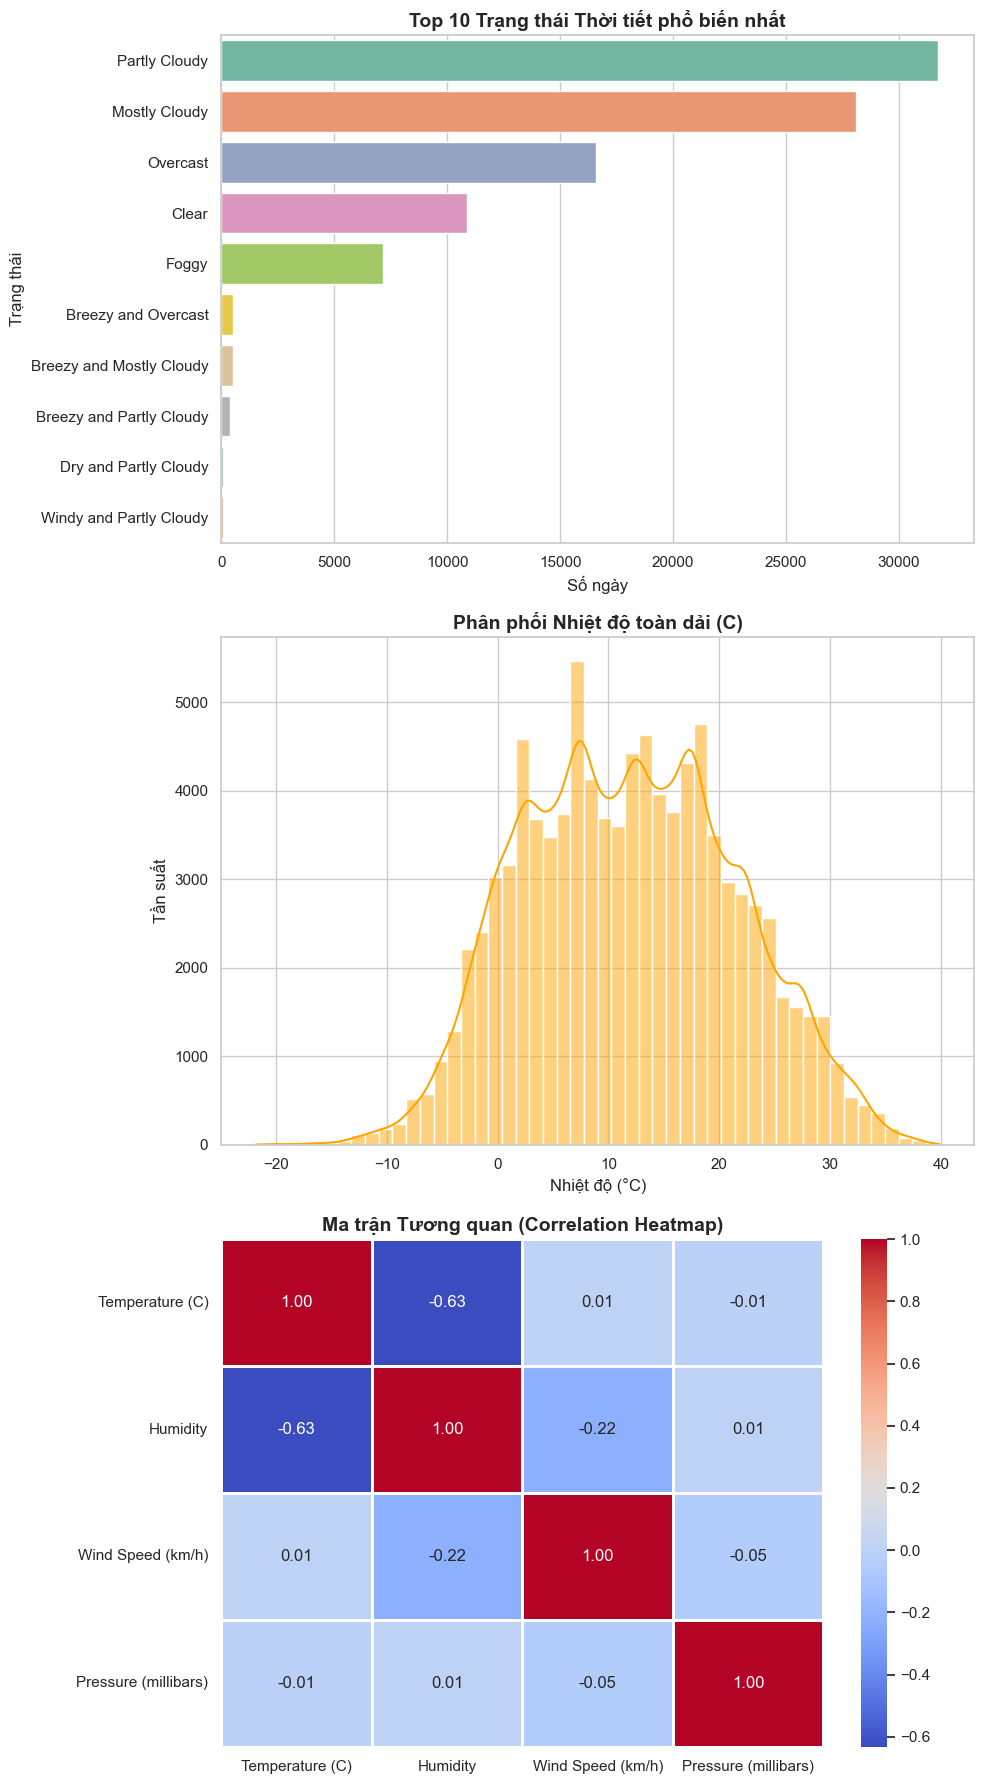

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import os

# Tự động đọc lại dữ liệu sạch để không bị lỗi NameError
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
with open("configs/params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
df_clean = pd.read_csv(config['data']['processed_path'])

print("📊 ĐANG VẼ BIỂU ĐỒ KHÁM PHÁ DỮ LIỆU (EDA)...\n")

# Cài đặt style cho biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# 1. Biểu đồ đếm số lượng các trạng thái thời tiết (Summary)
sns.countplot(data=df_clean, y='Summary', order=df_clean['Summary'].value_counts().index[:10], ax=axes[0], palette='Set2')
axes[0].set_title('Top 10 Trạng thái Thời tiết phổ biến nhất', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số ngày')
axes[0].set_ylabel('Trạng thái')

# 2. Phân phối Nhiệt độ (Histogram)
sns.histplot(df_clean['Temperature (C)'], bins=50, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Phân phối Nhiệt độ toàn dải (C)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nhiệt độ (°C)')
axes[1].set_ylabel('Tần suất')

# 3. Heatmap tương quan giữa các biến số
numeric_cols = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2], linewidths=1)
axes[2].set_title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()